In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install tensorboardX rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 20.0 MB/s eta 0:00:00


In [3]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data
torch.manual_seed(8) # for reproduce

import time
import numpy as np
import gc
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/code/')
sys.setrecursionlimit(50000)
import pickle
torch.backends.cudnn.benchmark = True
torch.set_default_tensor_type('torch.cuda.FloatTensor')
from tensorboardX import SummaryWriter
torch.nn.Module.dump_patches = True
import copy
import pandas as pd
#then import my own modules
from AttentiveFP import Fingerprint, Fingerprint_viz, save_smiles_dicts, get_smiles_dicts, get_smiles_array, moltosvg_highlight

/usr/local/lib/python3.10/dist-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [4]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import f1_score


In [5]:
# from rdkit.Chem import rdMolDescriptors, MolSurf
# from rdkit.Chem.Draw import SimilarityMaps
from rdkit import Chem
# from rdkit.Chem import AllChem
from rdkit.Chem import QED
%matplotlib inline
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
from IPython.display import SVG, display
import seaborn as sns; sns.set(color_codes=True)

number of all smiles:  40
number of successfully processed smiles:  40


<ipython-input-49-434d8772abaf>:38: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(atom_num_dist, bins=28, kde=False)


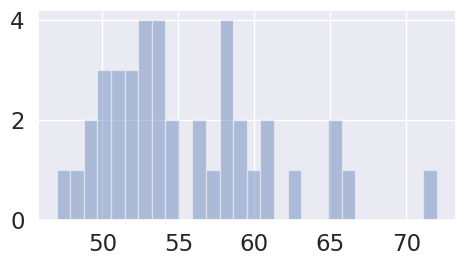

In [49]:
task_name = 'Calx'
tasks = ['H3K4','H3K4ac','H3K4me1','H3K4me2','H3K4me3','H3K9me3','H3R2me2a','H3R2me2s']
#tasks = ['H3K4']


raw_filename = '/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/data/Categorical prediction data.csv'
feature_filename = raw_filename.replace('.csv','.pickle')
filename = raw_filename.replace('.csv','')
prefix_filename = raw_filename.split('/')[-1].replace('.csv','')
smiles_tasks_df = pd.read_csv(raw_filename)

# Apply the transformation only to the specified columns
for column in tasks:
    smiles_tasks_df[column] = smiles_tasks_df[column].apply(lambda x: 1 if x > 0 else 0)

smilesList = smiles_tasks_df.SMILES.values
print("number of all smiles: ",len(smilesList))
atom_num_dist = []
remained_smiles = []
canonical_smiles_list = []
for smiles in smilesList:
    try:
        mol = Chem.MolFromSmiles(smiles)
        atom_num_dist.append(len(mol.GetAtoms()))
        remained_smiles.append(smiles)
        canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
    except:
        print("not successfully processed smiles: ", smiles)
        pass
print("number of successfully processed smiles: ", len(remained_smiles))
smiles_tasks_df = smiles_tasks_df[smiles_tasks_df["SMILES"].isin(remained_smiles)]
# print(smiles_tasks_df)
smiles_tasks_df['cano_smiles'] =canonical_smiles_list
assert canonical_smiles_list[8]==Chem.MolToSmiles(Chem.MolFromSmiles(smiles_tasks_df['cano_smiles'][8]), isomericSmiles=True)

plt.figure(figsize=(5, 3))
sns.set(font_scale=1.5)
ax = sns.distplot(atom_num_dist, bins=28, kde=False)
plt.tight_layout()
# plt.savefig("atom_num_dist_"+prefix_filename+".png",dpi=200)
plt.show()
plt.close()

# print(len([i for i in atom_num_dist if i<51]),len([i for i in atom_num_dist if i>50]))



number of all smiles:  40
number of successfully processed smiles:  40


<ipython-input-50-8bd38e5d081e>:23: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(atom_num_dist, bins=28, kde=False)


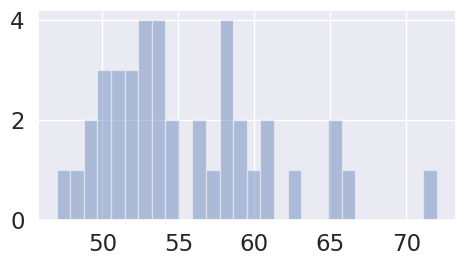

In [50]:
smilesList = smiles_tasks_df.SMILES.values
print("number of all smiles: ",len(smilesList))
atom_num_dist = []
remained_smiles = []
canonical_smiles_list = []
for smiles in smilesList:
    try:
        mol = Chem.MolFromSmiles(smiles)
        atom_num_dist.append(len(mol.GetAtoms()))
        remained_smiles.append(smiles)
        canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
    except:
        print("not successfully processed smiles: ", smiles)
        pass
print("number of successfully processed smiles: ", len(remained_smiles))
smiles_tasks_df = smiles_tasks_df[smiles_tasks_df["SMILES"].isin(remained_smiles)]
# print(smiles_tasks_df)
smiles_tasks_df['cano_smiles'] =canonical_smiles_list
assert canonical_smiles_list[8]==Chem.MolToSmiles(Chem.MolFromSmiles(smiles_tasks_df['cano_smiles'][8]), isomericSmiles=True)

plt.figure(figsize=(5, 3))
sns.set(font_scale=1.5)
ax = sns.distplot(atom_num_dist, bins=28, kde=False)
plt.tight_layout()
# plt.savefig("atom_num_dist_"+prefix_filename+".png",dpi=200)
plt.show()
plt.close()

# print(len([i for i in atom_num_dist if i<51]),len([i for i in atom_num_dist if i>50]))

In [51]:
random_seed = 888
start_time = str(time.ctime()).replace(':','-').replace(' ','_')
start = time.time()

batch_size = 100
epochs = 800
p_dropout = 0.5
fingerprint_dim = 200

radius = 3
T = 3
weight_decay = 3 # also known as l2_regularization_lambda
learning_rate = 3.5
per_task_output_units_num = 2 # for classification model with 2 classes
output_units_num = len(tasks) * per_task_output_units_num

In [52]:
smilesList = [smiles for smiles in canonical_smiles_list if len(Chem.MolFromSmiles(smiles).GetAtoms())<151]
uncovered = [smiles for smiles in canonical_smiles_list if len(Chem.MolFromSmiles(smiles).GetAtoms())>150]

smiles_tasks_df = smiles_tasks_df[~smiles_tasks_df["cano_smiles"].isin(uncovered)]

if os.path.isfile(feature_filename):
    feature_dicts = pickle.load(open(feature_filename, "rb" ))
else:
    feature_dicts = save_smiles_dicts(smilesList,filename)
# feature_dicts = get_smiles_dicts(smilesList)

remained_df = smiles_tasks_df[smiles_tasks_df["cano_smiles"].isin(feature_dicts['smiles_to_atom_mask'].keys())]
uncovered_df = smiles_tasks_df.drop(remained_df.index)
remained_df

,Host,H3K4,H3K4ac,H3K4me1,H3K4me2,H3K4me3,H3K9me3,H3R2me2a,H3R2me2s,SMILES,cano_smiles
0,PSC4,0,0,0,0,0,0,0,0,OC1=C(C=C(C=C1CC2=C(C(C3)=CC(S(=O)(O)=O)=C2)O)...,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...
1,PSC6,1,1,1,1,1,1,1,1,OC1=C2C=C(S(=O)(O)=O)C=C1CC3=C(O)C(CC4=CC(S(=O...,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...
2,P-NO2,0,0,0,0,0,0,0,0,OC1=C(CC2=CC([N+]([O-])=O)=CC(C3)=C2O)C=C(S(=O...,O=[N+]([O-])c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(...
3,AP1,0,0,1,1,1,1,1,1,OC1=C(C=C(C=C1CC2=C(C(C3)=CC(S(=O)(O)=O)=C2)O)...,O=C(O)Cc1ccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)c...
4,AP3,1,1,0,0,0,0,1,0,OC1=C(C=C(C=C1CC2=C(C(C3)=CC(S(=O)(O)=O)=C2)O)...,CC(C)(C)c1ccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)...
5,AP4,0,0,0,0,0,1,0,0,OC1=C(C=C(C=C1CC2=C(C(C3)=CC(S(=O)(O)=O)=C2)O)...,Cc1ccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)cc(c2O)...
6,AP5,0,0,0,0,1,1,1,0,OC1=C(C=C(C=C1CC2=C(C(C3)=CC(S(=O)(O)=O)=C2)O)...,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...
7,AP6,1,1,1,1,1,1,1,1,OC1=C(C=C(C=C1CC2=C(C(C3)=CC(S(=O)(O)=O)=C2)O)...,O=C(O)C[C@H](NC(=O)c1ccc(-c2cc3c(O)c(c2)Cc2cc(...
8,AP7,1,1,1,1,1,1,1,1,OC1=C(C=C(C=C1CC2=C(C(C3)=CC(S(=O)(O)=O)=C2)O)...,NC(=O)[C@H](CC(=O)O)NC(=O)c1ccc(-c2cc3c(O)c(c2...
9,AP8,1,1,1,1,1,1,1,1,OC1=C(CC2=CC(S(=O)(O)=O)=CC(CC3=CC(S(=O)(O)=O)...,O=C(N[C@@H](Cc1ccc(O)cc1)C(=O)O)c1ccc(-c2cc3c(...


In [53]:
weights = []
positive_dist = []
negative_dist = []
for i,task in enumerate(tasks):
    negative_df = remained_df[remained_df[task] == 0][["cano_smiles",task]]
    positive_df = remained_df[remained_df[task] == 1][["cano_smiles",task]]
    try:
        weights.append([(positive_df.shape[0]+negative_df.shape[0])/negative_df.shape[0],\
                        (positive_df.shape[0]+negative_df.shape[0])/positive_df.shape[0]])
    except:
        weights.append([1,1])

#     print(positive_test.shape[0],negative_test.shape[0])

    negative_dist.append(negative_df.shape[0])
    positive_dist.append(positive_df.shape[0])
    if len(negative_df)!=0:
        print(1)
        negative_test = negative_df.sample(frac=0.1,random_state=68)
        negative_valid = negative_df.drop(negative_test.index).sample(frac=1/9,random_state=68)
        negative_train = negative_df.drop(negative_test.index).drop(negative_valid.index)
    else:
        print(11)
        negative_test = negative_df
        negative_valid = negative_df
        negative_train = negative_df

    if len(positive_df)!=0:
        print(2)
        positive_test = positive_df.sample(frac=0.1,random_state=68)
        positive_valid = positive_df.drop(positive_test.index).sample(frac=1/9,random_state=68)
        positive_train = positive_df.drop(positive_test.index).drop(positive_valid.index)
    else:
        print(22)
        positive_test = positive_df
        positive_valid = positive_df
        positive_train = positive_df

    train_df_new = pd.concat([negative_train,positive_train])
    valid_df_new = pd.concat([negative_valid,positive_valid])
    test_df_new = pd.concat([negative_test,positive_test])
    if i==0:
        print(3)
        train_df = train_df_new
        test_df = test_df_new
        valid_df = valid_df_new
    else:
        print(33)
        train_df = pd.merge(train_df, train_df_new, on='cano_smiles', how='outer')
        test_df = pd.merge(test_df, test_df_new, on='cano_smiles', how='outer')
        valid_df = pd.merge(valid_df, valid_df_new, on='cano_smiles', how='outer')


1
2
3
1
2
33
1
2
33
1
2
33
1
2
33
1
2
33
1
2
33
1
2
33


In [45]:
train_df

,cano_smiles,H3K4
0,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...,0
6,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...,0
11,CC(=O)c1cccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)c...,0
17,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...,0
18,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...,0
19,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...,0
20,Cc1ccccc1-c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...,0
21,COc1ccccc1-c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c...,0
22,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...,0
23,O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(-c3ccccc3)cc(c1O...,0


In [54]:
x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array([smilesList[0]],feature_dicts)
num_atom_features = x_atom.shape[-1]
num_bond_features = x_bonds.shape[-1]

loss_function = [nn.CrossEntropyLoss(torch.Tensor(weight),reduction='mean') for weight in weights]
model = Fingerprint(radius, T, num_atom_features,num_bond_features,
            fingerprint_dim, output_units_num, p_dropout)
model.cuda()
# tensorboard = SummaryWriter(log_dir="runs/"+start_time+"_"+prefix_filename+"_"+str(fingerprint_dim)+"_"+str(p_dropout))

# optimizer = optim.Adam(model.parameters(), learning_rate, weight_decay=weight_decay)
optimizer = optim.Adam(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(params)
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data.shape)


1148420
atom_fc.weight torch.Size([200, 39])
atom_fc.bias torch.Size([200])
neighbor_fc.weight torch.Size([200, 49])
neighbor_fc.bias torch.Size([200])
GRUCell.0.weight_ih torch.Size([600, 200])
GRUCell.0.weight_hh torch.Size([600, 200])
GRUCell.0.bias_ih torch.Size([600])
GRUCell.0.bias_hh torch.Size([600])
GRUCell.1.weight_ih torch.Size([600, 200])
GRUCell.1.weight_hh torch.Size([600, 200])
GRUCell.1.bias_ih torch.Size([600])
GRUCell.1.bias_hh torch.Size([600])
GRUCell.2.weight_ih torch.Size([600, 200])
GRUCell.2.weight_hh torch.Size([600, 200])
GRUCell.2.bias_ih torch.Size([600])
GRUCell.2.bias_hh torch.Size([600])
align.0.weight torch.Size([1, 400])
align.0.bias torch.Size([1])
align.1.weight torch.Size([1, 400])
align.1.bias torch.Size([1])
align.2.weight torch.Size([1, 400])
align.2.bias torch.Size([1])
attend.0.weight torch.Size([200, 200])
attend.0.bias torch.Size([200])
attend.1.weight torch.Size([200, 200])
attend.1.bias torch.Size([200])
attend.2.weight torch.Size([200, 200]

In [55]:
def train(model, dataset, optimizer, loss_function):
    model.train()
    np.random.seed(epoch)
    valList = np.arange(0,dataset.shape[0])
    #shuffle them
    np.random.shuffle(valList)
    batch_list = []
    for i in range(0, dataset.shape[0], batch_size):
        batch = valList[i:i+batch_size]
        batch_list.append(batch)
    for counter, train_batch in enumerate(batch_list):
        batch_df = dataset.loc[train_batch,:]
        smiles_list = batch_df.cano_smiles.values

        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array(smiles_list,feature_dicts)
        atoms_prediction, mol_prediction = model(torch.Tensor(x_atom),torch.Tensor(x_bonds),torch.cuda.LongTensor(x_atom_index),torch.cuda.LongTensor(x_bond_index),torch.Tensor(x_mask))
#         print(torch.Tensor(x_atom).size(),torch.Tensor(x_bonds).size(),torch.cuda.LongTensor(x_atom_index).size(),torch.cuda.LongTensor(x_bond_index).size(),torch.Tensor(x_mask).size())

        optimizer.zero_grad()
        loss = 0.0
        for i,task in enumerate(tasks):
            y_pred = mol_prediction[:, i * per_task_output_units_num:(i + 1) *
                                    per_task_output_units_num]
            y_val = batch_df[task].values

            validInds = np.where((y_val==0) | (y_val==1))[0]
#             validInds = np.where(y_val != -1)[0]
            if len(validInds) == 0:
                continue
            y_val_adjust = np.array([y_val[v] for v in validInds]).astype(float)
            validInds = torch.cuda.LongTensor(validInds).squeeze()
            y_pred_adjust = torch.index_select(y_pred, 0, validInds)

            loss += loss_function[i](
                y_pred_adjust,
                torch.cuda.LongTensor(y_val_adjust))
        # Step 5. Do the backward pass and update the gradient
        loss.backward()
        optimizer.step()
def eval(model, dataset):
    model.eval()
    y_val_list = {}
    y_pred_list = {}
    losses_list = []
    valList = np.arange(0,dataset.shape[0])
    batch_list = []
    for i in range(0, dataset.shape[0], batch_size):
        batch = valList[i:i+batch_size]
        batch_list.append(batch)
    for counter, eval_batch in enumerate(batch_list):
        batch_df = dataset.loc[eval_batch,:]
        smiles_list = batch_df.cano_smiles.values

        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array(smiles_list,feature_dicts)
        atoms_prediction, mol_prediction = model(torch.Tensor(x_atom),torch.Tensor(x_bonds),torch.cuda.LongTensor(x_atom_index),torch.cuda.LongTensor(x_bond_index),torch.Tensor(x_mask))
        atom_pred = atoms_prediction.data[:,:,1].unsqueeze(2).cpu().numpy()
        for i,task in enumerate(tasks):
            y_pred = mol_prediction[:, i * per_task_output_units_num:(i + 1) *
                                    per_task_output_units_num]
            y_val = batch_df[task].values

            validInds = np.where((y_val==0) | (y_val==1))[0]
#             validInds = np.where((y_val=='0') | (y_val=='1'))[0]
#             print(validInds)
            if len(validInds) == 0:
                continue
            y_val_adjust = np.array([y_val[v] for v in validInds]).astype(float)
            validInds = torch.cuda.LongTensor(validInds).squeeze()
            y_pred_adjust = torch.index_select(y_pred, 0, validInds)
#             print(validInds)
            loss = loss_function[i](
                y_pred_adjust,
                torch.cuda.LongTensor(y_val_adjust))
#             print(y_pred_adjust)
            y_pred_adjust = F.softmax(y_pred_adjust,dim=-1).data.cpu().numpy()[:,1]
            losses_list.append(loss.cpu().detach().numpy())
            try:
                y_val_list[i].extend(y_val_adjust)
                y_pred_list[i].extend(y_pred_adjust)
            except:
                y_val_list[i] = []
                y_pred_list[i] = []
                y_val_list[i].extend(y_val_adjust)
                y_pred_list[i].extend(y_pred_adjust)

    eval_roc = [roc_auc_score(y_val_list[i], y_pred_list[i]) for i in range(len(tasks))]
#     eval_prc = [auc(precision_recall_curve(y_val_list[i], y_pred_list[i])[1],precision_recall_curve(y_val_list[i], y_pred_list[i])[0]) for i in range(len(tasks))]
#     eval_precision = [precision_score(y_val_list[i],
#                                      (np.array(y_pred_list[i]) > 0.5).astype(int)) for i in range(len(tasks))]
#     eval_recall = [recall_score(y_val_list[i],
#                                (np.array(y_pred_list[i]) > 0.5).astype(int)) for i in range(len(tasks))]
    eval_loss = np.array(losses_list).mean()

    return eval_roc, eval_loss #eval_prc, eval_precision, eval_recall,


In [56]:
best_param ={}
best_param["roc_epoch"] = 0
best_param["loss_epoch"] = 0
best_param["valid_roc"] = 0
best_param["valid_loss"] = 9e8

for epoch in range(epochs):
    train_roc, train_loss = eval(model, train_df)
    valid_roc, valid_loss = eval(model, valid_df)
    train_roc_mean = np.array(train_roc).mean()
    valid_roc_mean = np.array(valid_roc).mean()

#     tensorboard.add_scalars('ROC',{'train_roc':train_roc_mean,'valid_roc':valid_roc_mean},epoch)
#     tensorboard.add_scalars('Losses',{'train_losses':train_loss,'valid_losses':valid_loss},epoch)

    if valid_roc_mean > best_param["valid_roc"]:
        best_param["roc_epoch"] = epoch
        best_param["valid_roc"] = valid_roc_mean
        if valid_roc_mean > 0.9:
             torch.save(model, '/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/code/saved_models/mod_'+prefix_filename+'_'+start_time+'_'+str(epoch)+'.pt')
             print('/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/code/saved_models/mod_'+prefix_filename+'_'+start_time+'_'+str(epoch)+'.pt')
    if valid_loss < best_param["valid_loss"]:
        best_param["loss_epoch"] = epoch
        best_param["valid_loss"] = valid_loss

    print("EPOCH:\t"+str(epoch)+'\n'\
#         +"train_roc"+":"+str(train_roc)+'\n'\
#         +"valid_roc"+":"+str(valid_roc)+'\n'\
        +"train_roc_mean"+":"+str(train_roc_mean)+'\n'\
        +"valid_roc_mean"+":"+str(valid_roc_mean)+'\n'\
        )
    if (epoch - best_param["roc_epoch"] >10) and (epoch - best_param["loss_epoch"] >20):
        break

    train(model, train_df, optimizer, loss_function)


EPOCH:	0
train_roc_mean:0.5047181372549019
valid_roc_mean:0.5

EPOCH:	1
train_roc_mean:0.5619034397613212
valid_roc_mean:0.71875

EPOCH:	2
train_roc_mean:0.5387085758782679
valid_roc_mean:0.6875

EPOCH:	3
train_roc_mean:0.5309356945903361
valid_roc_mean:0.65625

EPOCH:	4
train_roc_mean:0.5727861391952614
valid_roc_mean:0.6875

EPOCH:	5
train_roc_mean:0.6121972291520775
valid_roc_mean:0.6875

EPOCH:	6
train_roc_mean:0.64237392222514
valid_roc_mean:0.71875

EPOCH:	7
train_roc_mean:0.6478901326155462
valid_roc_mean:0.75

EPOCH:	8
train_roc_mean:0.6583804289945145
valid_roc_mean:0.875

/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/code/saved_models/mod_Categorical prediction data_Fri_Jan_19_06-41-57_2024_9.pt
EPOCH:	9
train_roc_mean:0.6691340142827965
valid_roc_mean:0.9375

/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/code/saved_models/mod_Categorical prediction data_Fri_Jan_19_06-41-57_2024_10.pt
EPOCH:	10
train_roc_mean:0.675733470471522
valid_roc_mean:

The resulting roc list will be very long, because there are 617 tasks in this dataset.

In [58]:
# evaluate model
best_model = torch.load('/content/drive/MyDrive/Colab Notebooks/Drug_Project/Native_AFP/code/saved_models/mod_Categorical prediction data_Fri_Jan_19_05-39-34_2024_2.pt')

best_model_dict = best_model.state_dict()
best_model_wts = copy.deepcopy(best_model_dict)

model.load_state_dict(best_model_wts)
(best_model.align[0].weight == model.align[0].weight).all()
test_roc, test_losses = eval(model, valid_df)


print("best epoch:"+str(best_param["roc_epoch"])
      +"\n"+"test_roc:"+str(test_roc)
      +"\n"+"test_roc_mean:",str(np.array(test_roc).mean())
     )

best epoch:10
test_roc:[0.5, 1.0, 1.0, 0.75, 1.0, 1.0, 1.0, 1.0]
test_roc_mean: 0.90625
